<a href="https://colab.research.google.com/github/AlanMedeirosXCX/Atividade-Frontend/blob/main/C%C3%B3pia_de_Aula_16_09_KNN_Professor_Demonstracao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 16/09 — Aprendizado Supervisionado: KNN
## Notebook demonstrativo do professor — Breast Cancer Wisconsin

**Mapa:** Machine Learning → Supervisionado → Classificação → KNN

**Problema:** usar características numéricas para prever uma classe (maligna/benigna).

O objetivo não é decorar `KNeighborsClassifier()`. É entender por que usamos KNN, como distância, K e escala interferem no resultado e como avaliamos uma classificação.

> Dataset usado apenas para ensino de ML; não se propõe uso clínico.


## 1. Importações
Pandas organiza os dados; Seaborn/Matplotlib permitem EDA; scikit-learn fornece dataset, divisão, padronização, KNN e métricas.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
sns.set_theme(style="whitegrid")


## 2. Carregamento
Usamos um dataset embutido no scikit-learn para evitar download/autenticação em sala. Primeiro verificamos dimensão e primeiras observações.


In [ ]:
dados=load_breast_cancer(as_frame=True)
df=dados.frame.copy()
print(df.shape)
display(df.head())


(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Qual é o problema?
Temos target conhecido → **supervisionado**. Queremos uma categoria → **classificação**.  
`X` serão características; `y`, a classe.


In [ ]:
print(list(dados.target_names))
display(df["target"].value_counts().rename(index={0:"malignant",1:"benign"}))


[np.str_('malignant'), np.str_('benign')]


,count
target,
benign,357
malignant,212


## 4. EDA mínima
Mesmo na aula de modelo, mantemos o pipeline. Verificamos tipos, ausentes, target e magnitude das features. A pergunta crítica é: **as features possuem escalas diferentes?**


In [ ]:
display(df.describe().T[["mean","std","min","50%","max"]].head(15))
print("Ausentes:", df.isna().sum().sum())


,mean,std,min,50%,max
mean radius,14.127292,3.524049,6.981000,13.37000,28.11000
mean texture,19.289649,4.301036,9.710000,18.84000,39.28000
mean perimeter,91.969033,24.298981,43.790000,86.24000,188.50000
mean area,654.889104,351.914129,143.500000,551.10000,2501.00000
mean smoothness,0.096360,0.014064,0.052630,0.09587,0.16340
mean compactness,0.104341,0.052813,0.019380,0.09263,0.34540
mean concavity,0.088799,0.079720,0.000000,0.06154,0.42680
mean concave points,0.048919,0.038803,0.000000,0.03350,0.20120
mean symmetry,0.181162,0.027414,0.106000,0.17920,0.30400
mean fractal dimension,0.062798,0.007060,0.049960,0.06154,0.09744


Ausentes: 0


## 5. Espaço de features
Cada observação pode ser imaginada como um ponto. Com duas features conseguimos visualizar a geometria; com muitas, a ideia permanece.


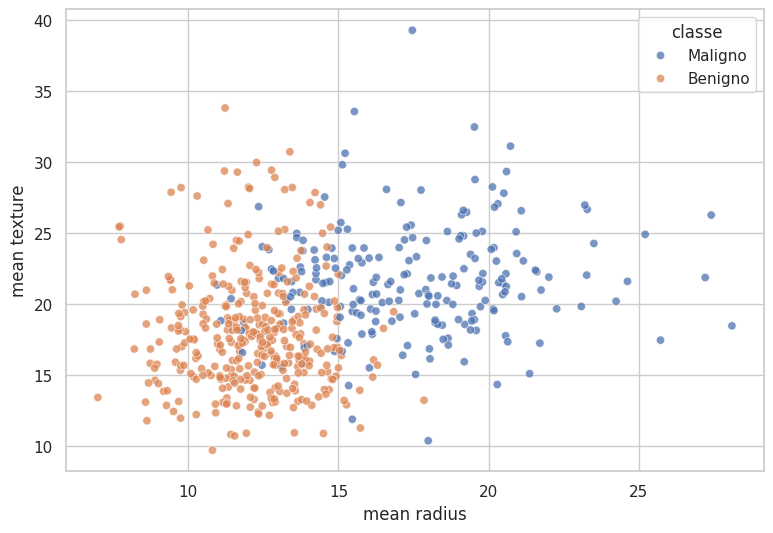

In [ ]:
df_plot=df.assign(classe=df["target"].map({0:"Maligno",1:"Benigno"}))
plt.figure(figsize=(9,6))
sns.scatterplot(data=df_plot,x="mean radius",y="mean texture",hue="classe",alpha=.75)
plt.show()


## 6. Distância euclidiana
\[
d(A,B)=\sqrt{\sum_{j=1}^{p}(A_j-B_j)^2}
\]
O KNN procura exemplos conhecidos próximos do novo ponto. “Próximo” depende da métrica de distância.


In [ ]:
A=np.array([10,20]); B=np.array([13,24])
print("Distância =", np.sqrt(((A-B)**2).sum()))


Distância = 5.0


## 7. Separando X e y
O target não pode entrar nas features. Entregar a resposta ao modelo como entrada seria **data leakage**.


In [ ]:
X=df.drop(columns="target")
y=df["target"]
print(X.shape,y.shape)


(569, 30) (569,)


## 8. Treino × teste
Treino fornece exemplos ao algoritmo; teste simula dados novos. `stratify=y` preserva aproximadamente a proporção das classes.


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=.25,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)


(426, 30) (143, 30)


## 9. Experimento proposital: KNN sem escala
Como KNN depende de distância, uma feature numericamente grande pode dominar outra pequena. Primeiro observamos o problema sem corrigir.


In [ ]:
knn_sem=KNeighborsClassifier(n_neighbors=5)
knn_sem.fit(X_train,y_train)
pred_sem=knn_sem.predict(X_test)
acc_sem=accuracy_score(y_test,pred_sem)
print("Accuracy sem escala:",acc_sem)


Accuracy sem escala: 0.9300699300699301


## 10. Padronização
\[
z=\frac{x-\mu}{\sigma}
\]
O `StandardScaler` aprende média e desvio **somente no treino**. O teste recebe apenas `transform`, evitando leakage.


In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
display(pd.DataFrame(X_train_scaled[:3,:5],columns=X_train.columns[:5]))


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,1.659096,0.217205,1.610620,1.633339,0.576312
1,-0.338165,-1.389968,-0.401667,-0.387017,-1.985604
2,0.874457,-0.651659,1.010370,0.761353,1.694102


## 11. KNN padronizado
`K=5` significa consultar cinco vizinhos. Com pesos uniformes, cada vizinho vota igualmente. KNN é baseado em instâncias: `fit()` não aprende uma reta como regressão linear.


In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
pred=knn.predict(X_test_scaled)
acc=accuracy_score(y_test,pred)
print("Accuracy padronizada:",acc)


Accuracy padronizada: 0.9790209790209791


## 12. Comparando escala
Esta é a conexão direta com 26/08: escala deixou de ser conceito abstrato e passou a alterar quem é considerado “vizinho”.


,Pipeline,Accuracy
0,Sem escala,0.930070
1,Padronizado,0.979021


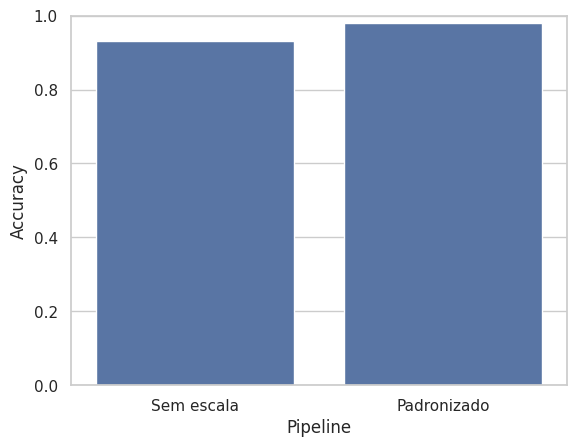

In [ ]:
comp=pd.DataFrame({"Pipeline":["Sem escala","Padronizado"],"Accuracy":[acc_sem,acc]})
display(comp)
sns.barplot(data=comp,x="Pipeline",y="Accuracy")
plt.ylim(0,1); plt.show()


## 13. Abrindo o predict()
`kneighbors()` permite mostrar as distâncias e classes dos vizinhos de uma observação. Assim o aluno enxerga de onde vem a decisão.


In [ ]:
dist,idx=knn.kneighbors(X_test_scaled[0].reshape(1,-1),n_neighbors=5)
display(pd.DataFrame({"distancia":dist[0],"classe":y_train.iloc[idx[0]].to_numpy()}))
print("Real:",y_test.iloc[0],"Prevista:",pred[0])


,distancia,classe
0,1.976692,1
1,2.148792,1
2,2.193188,1
3,2.205316,1
4,2.234937,1


Real: 1 Prevista: 1


## 14. O K é hiperparâmetro
K pequeno → decisão muito local/sensível. K maior → suaviza. K grande demais → pode apagar padrões locais. A comparação abaixo é didática; escolha rigorosa será retomada com validação cruzada.


,K,Accuracy
0,1,0.951049
1,3,0.972028
2,5,0.979021
3,7,0.979021
4,9,0.965035
5,11,0.972028
6,15,0.958042
7,21,0.944056


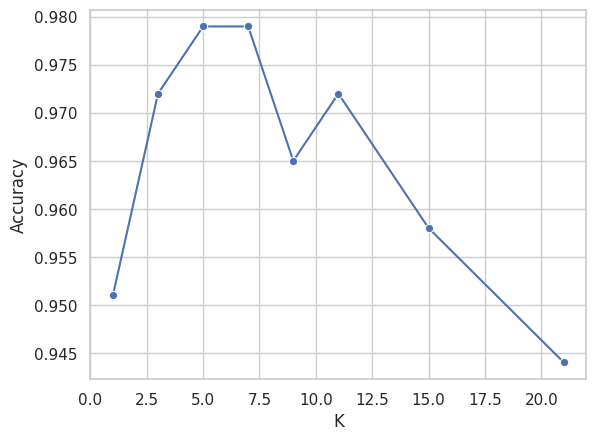

In [ ]:
resultados=pd.DataFrame({
"K":[1,3,5,7,9,11,15,21],
"Accuracy":[
KNeighborsClassifier(n_neighbors=1).fit(X_train_scaled,y_train).score(X_test_scaled,y_test),
KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled,y_train).score(X_test_scaled,y_test),
KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled,y_train).score(X_test_scaled,y_test),
KNeighborsClassifier(n_neighbors=7).fit(X_train_scaled,y_train).score(X_test_scaled,y_test),
KNeighborsClassifier(n_neighbors=9).fit(X_train_scaled,y_train).score(X_test_scaled,y_test),
KNeighborsClassifier(n_neighbors=11).fit(X_train_scaled,y_train).score(X_test_scaled,y_test),
KNeighborsClassifier(n_neighbors=15).fit(X_train_scaled,y_train).score(X_test_scaled,y_test),
KNeighborsClassifier(n_neighbors=21).fit(X_train_scaled,y_train).score(X_test_scaled,y_test)]})
display(resultados)
sns.lineplot(data=resultados,x="K",y="Accuracy",marker="o"); plt.show()


## 15. Matriz de confusão
Accuracy mostra acertos totais, mas não quais classes foram confundidas. A matriz cruza classe real × prevista.


,Prev Maligno,Prev Benigno
Real Maligno,50,3
Real Benigno,0,90


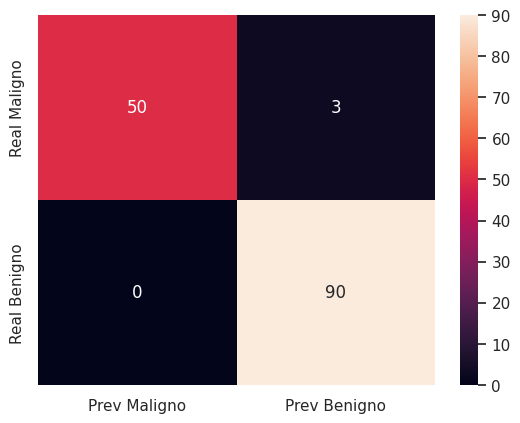

In [ ]:
cm=confusion_matrix(y_test,pred)
cm=pd.DataFrame(cm,index=["Real Maligno","Real Benigno"],
columns=["Prev Maligno","Prev Benigno"])
display(cm)
sns.heatmap(cm,annot=True,fmt="d"); plt.show()


## 16. Precision, Recall e F1
**Precision:** entre os que o modelo chamou de uma classe, quantos estavam corretos?  
**Recall:** entre os que realmente pertenciam à classe, quantos foram encontrados?  
**F1:** combina precision e recall.


In [ ]:
print(classification_report(y_test,pred,target_names=["Maligno","Benigno"]))


              precision    recall  f1-score   support

     Maligno       1.00      0.94      0.97        53
     Benigno       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



## 17. Fechamento
Volte ao pipeline:

**Problema → Dataset → EDA → Preparação → Hipótese → Modelo → Avaliação → Interpretação**

Perguntas finais: por que supervisionado? por que classificação? o que são X/y? por que split? por que escala? o que é K? o que `predict()` faz? por que accuracy não basta?
